# Inicio

In [4]:
# Importación de librerías necesarias
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

# Gráficos y Visualización
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')
import seaborn as sns
import missingno as msno

# Preprocesado, Reducción de Dimensionalidad y Modelado
from sklearn.cluster import KMeans
from sklearn.preprocessing import scale, StandardScaler
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

In [5]:
# Carga del dataset desde el almacenamiento local
url = 'segmentacion 1.csv'
data = pd.read_csv(url, delimiter=',')

In [6]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0


# EDA

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [8]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0


In [9]:
# Conversión de la columna de fecha a formato datetime para cálculos de antigüedad
data['Dt_Customer'] = data['Dt_Customer'].astype('datetime64[ns]')

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   str           
 3   Marital_Status       2240 non-null   str           
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-null   int64  

In [11]:
data.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,2013-09-09,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,2012-11-13,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,2013-05-08,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,2013-06-06,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,2014-03-13,68,28,...,20,1,0,0,0,0,0,3,11,0


In [12]:
data.isnull()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2236,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2237,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2238,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
# Verificación de valores nulos por columna
display(data.isnull().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

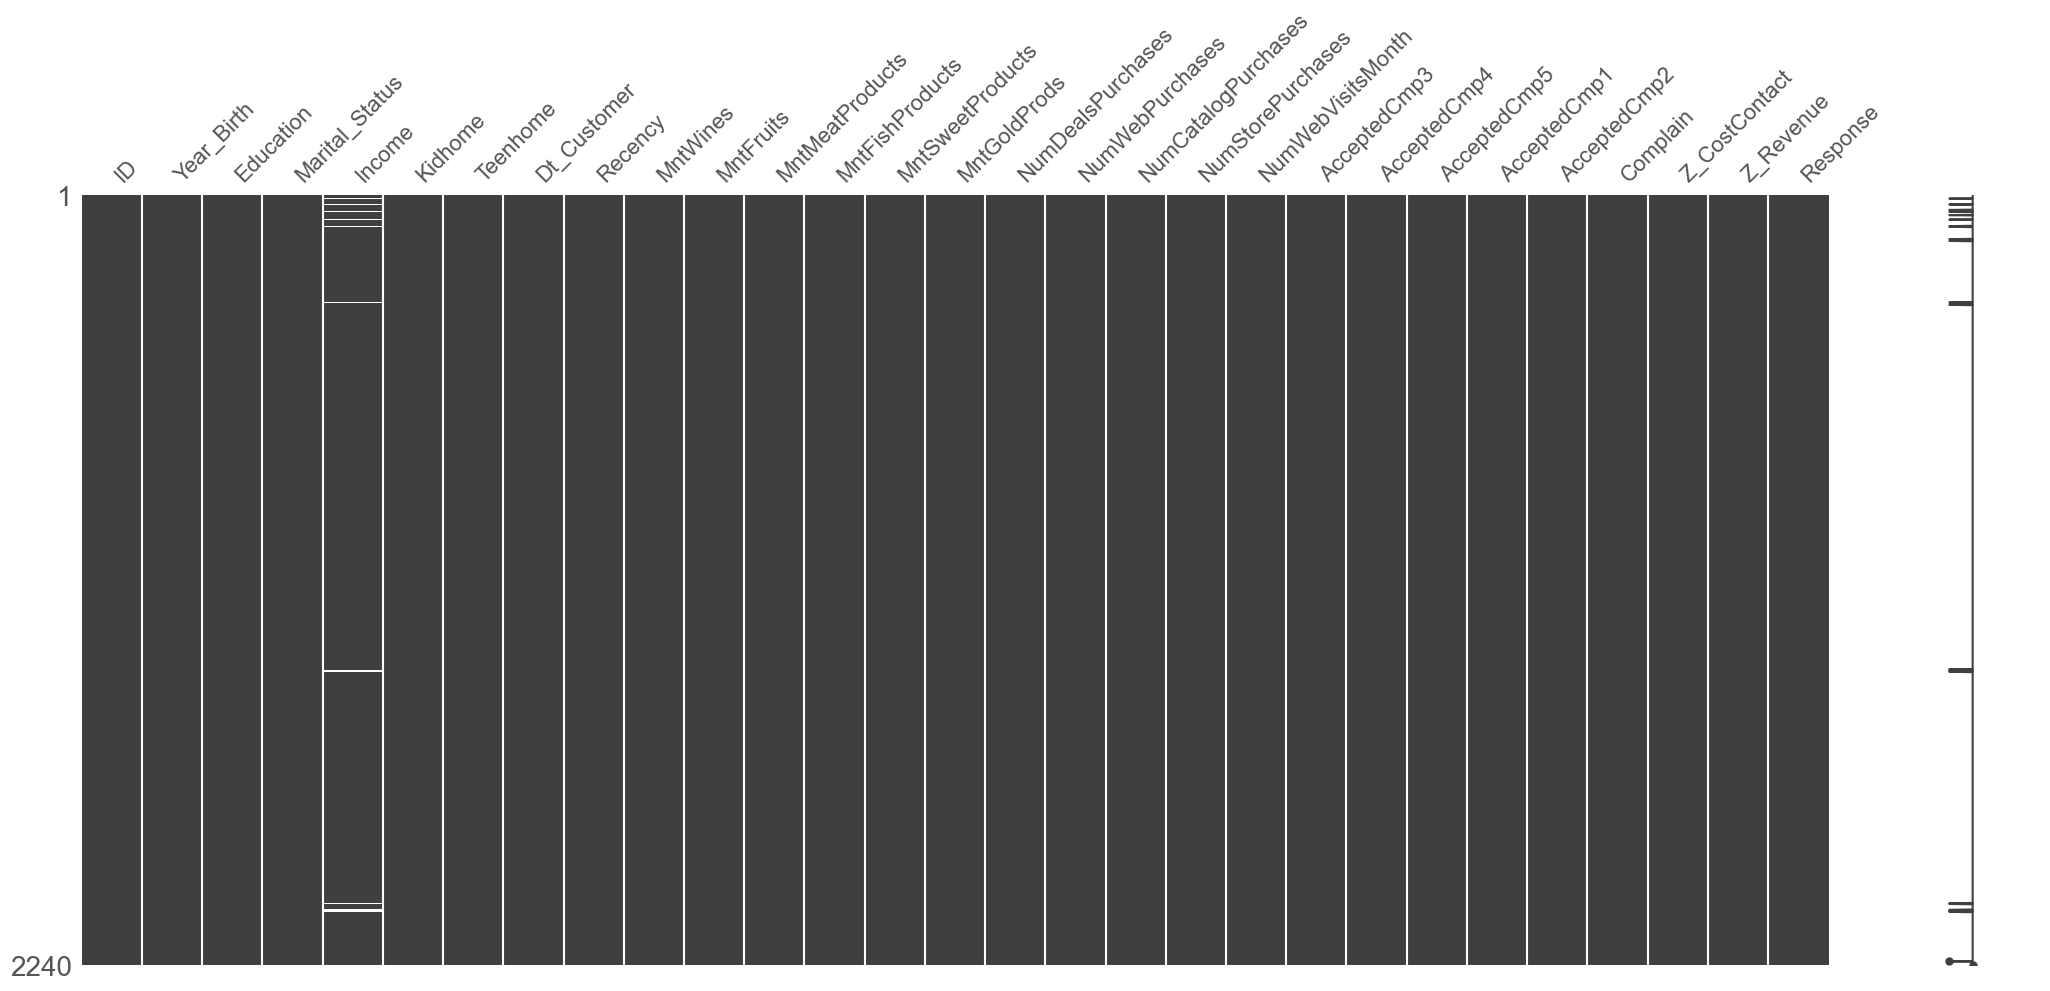

In [14]:
msno.matrix(data)
plt.show()

In [15]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
ID,2240.0,5592.159821,0.0,2828.25,5458.5,8427.75,11191.0,3246.662198
Year_Birth,2240.0,1968.805804,1893.0,1959.0,1970.0,1977.0,1996.0,11.984069
Income,2216.0,52247.251354,1730.0,35303.0,51381.5,68522.0,666666.0,25173.076661
Kidhome,2240.0,0.444196,0.0,0.0,0.0,1.0,2.0,0.538398
Teenhome,2240.0,0.50625,0.0,0.0,0.0,1.0,2.0,0.544538
Dt_Customer,2240,2013-07-10 10:01:42.857142784,2012-07-30 00:00:00,2013-01-16 00:00:00,2013-07-08 12:00:00,2013-12-30 06:00:00,2014-06-29 00:00:00,NaN
Recency,2240.0,49.109375,0.0,24.0,49.0,74.0,99.0,28.962453
MntWines,2240.0,303.935714,0.0,23.75,173.5,504.25,1493.0,336.597393
MntFruits,2240.0,26.302232,0.0,1.0,8.0,33.0,199.0,39.773434
MntMeatProducts,2240.0,166.95,0.0,16.0,67.0,232.0,1725.0,225.715373


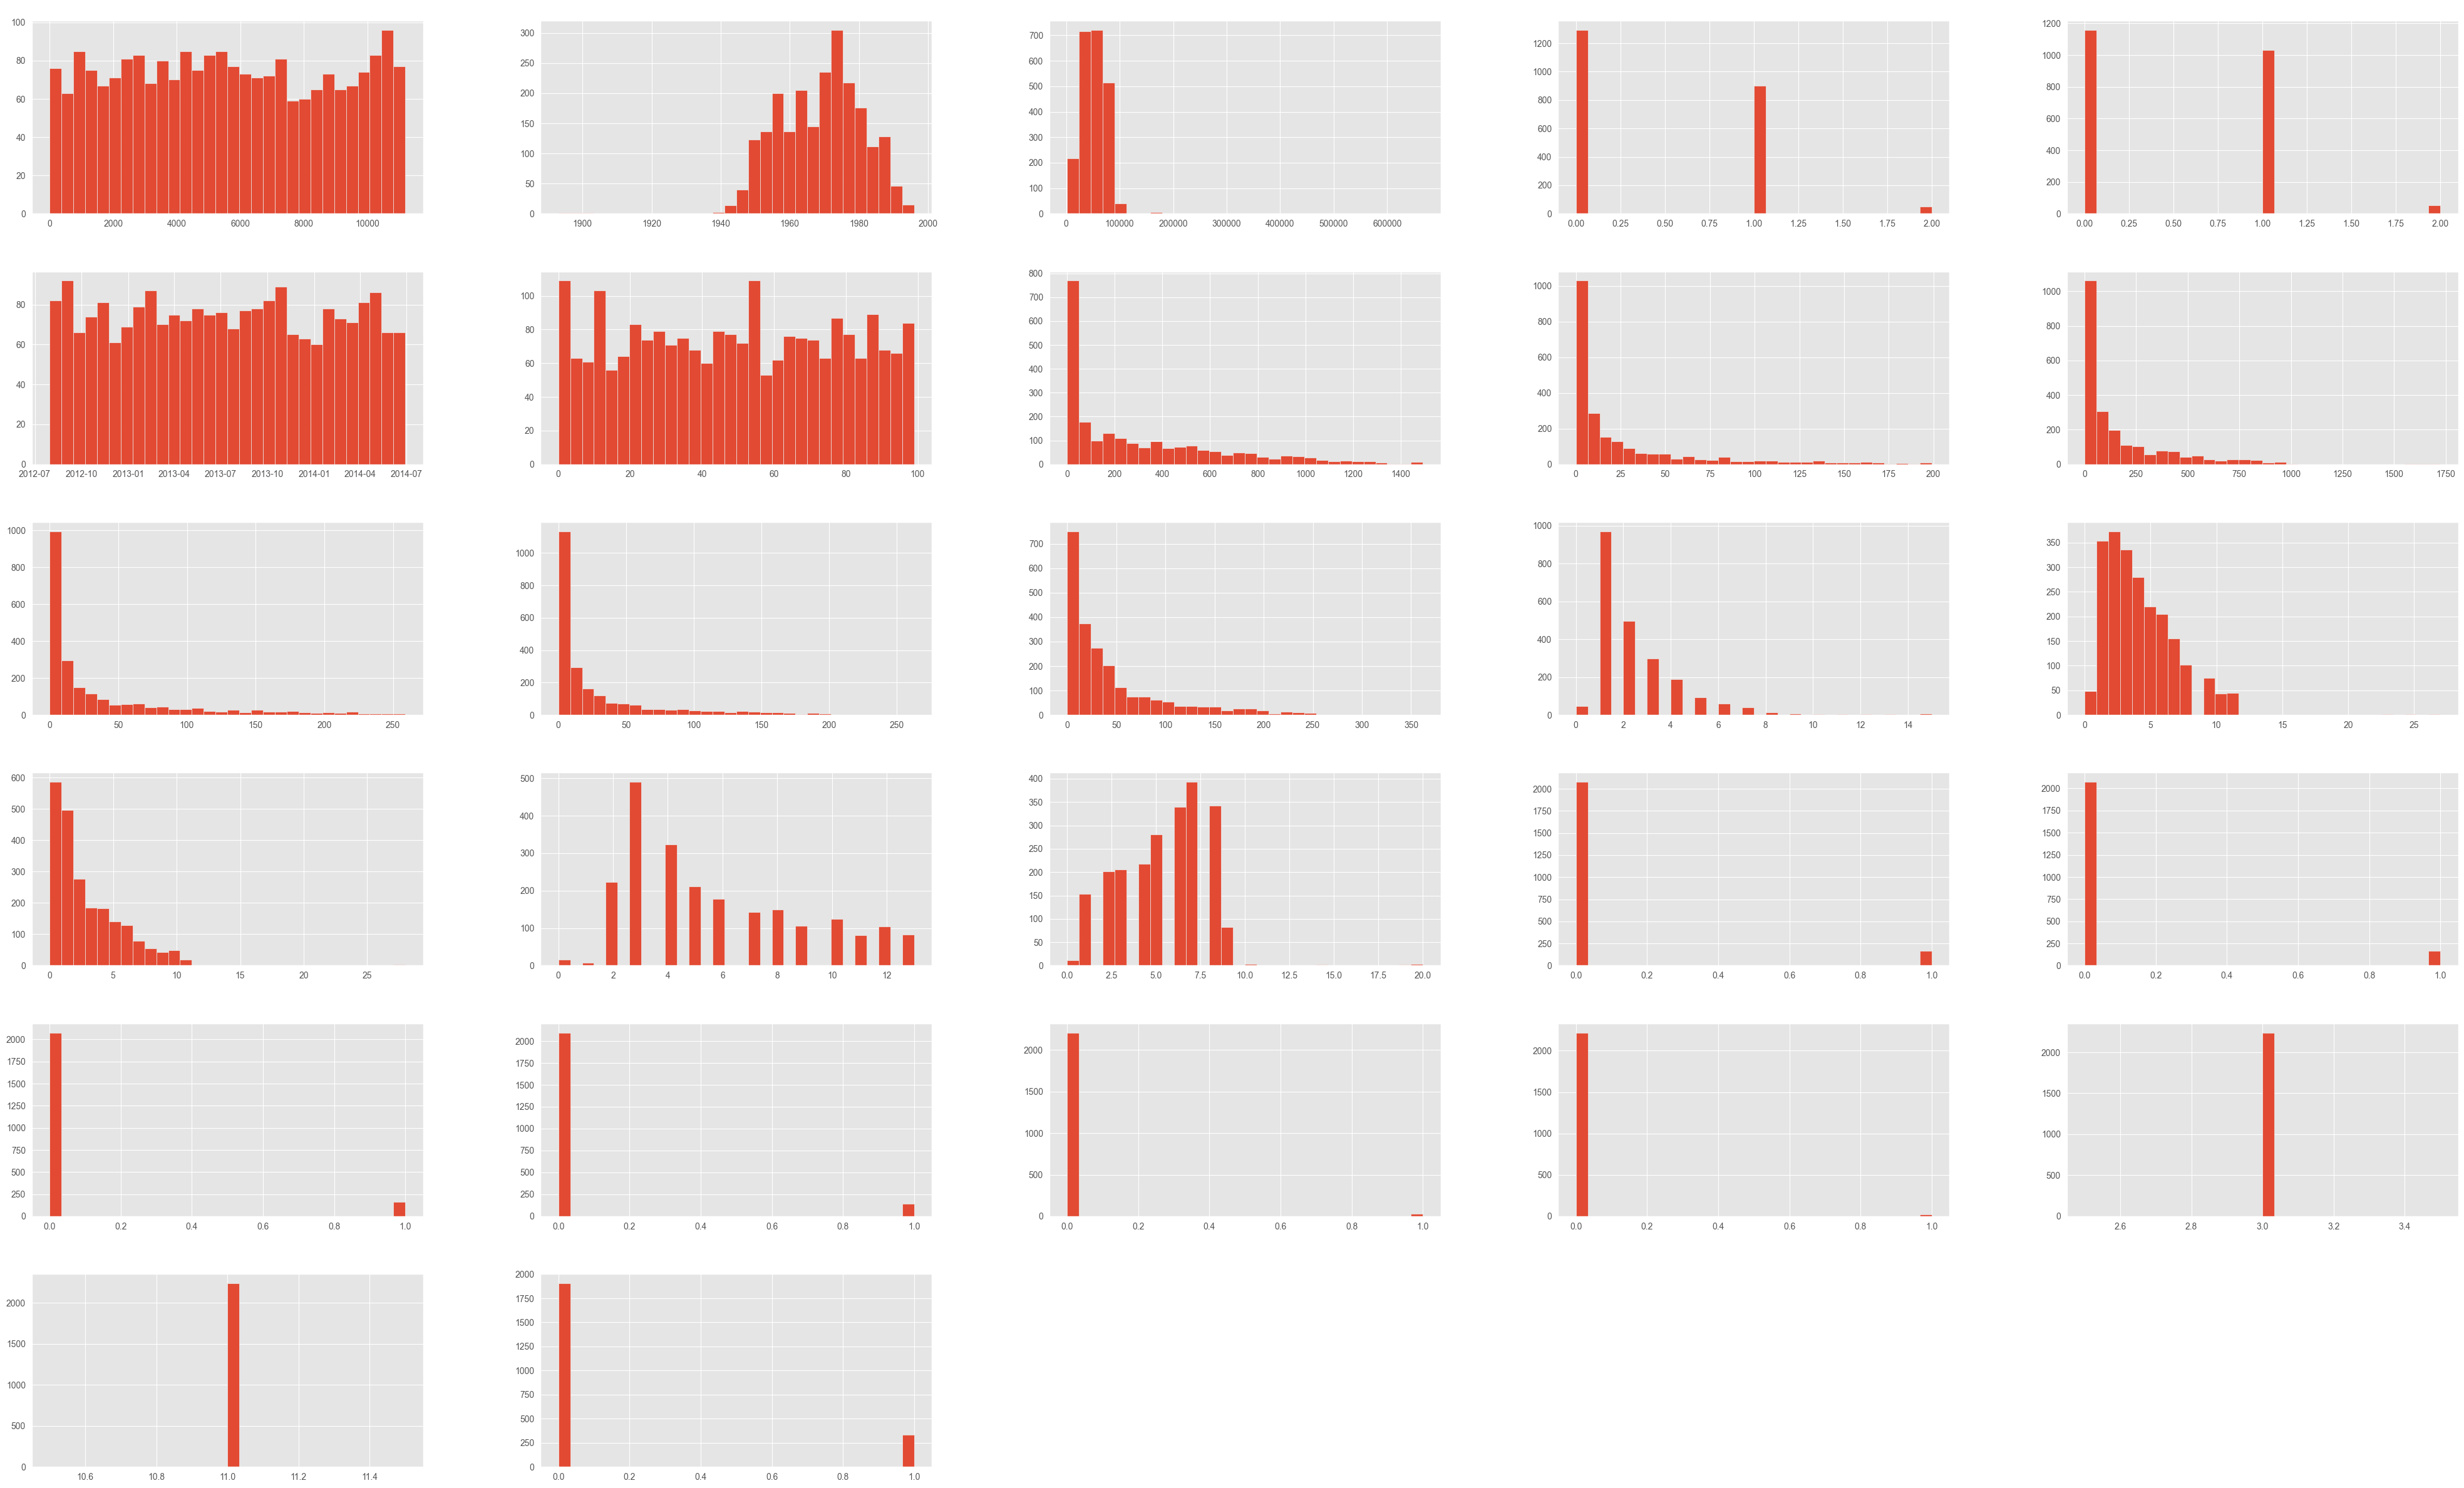

In [16]:
# Histogramas de variables numéricas
data.hist(figsize=(50, 30), bins=30)
plt.show()

In [17]:
data.select_dtypes(include=[np.number])



,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,58138.0,0,0,58,635,88,546,172,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,46344.0,1,1,38,11,1,6,2,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,71613.0,0,0,26,426,49,127,111,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,26646.0,1,0,26,11,4,20,10,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,58293.0,1,0,94,173,43,118,46,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,61223.0,0,1,46,709,43,182,42,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,64014.0,2,1,56,406,0,30,0,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,56981.0,0,0,91,908,48,217,32,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,69245.0,0,1,8,428,30,214,80,...,3,0,0,0,0,0,0,3,11,0


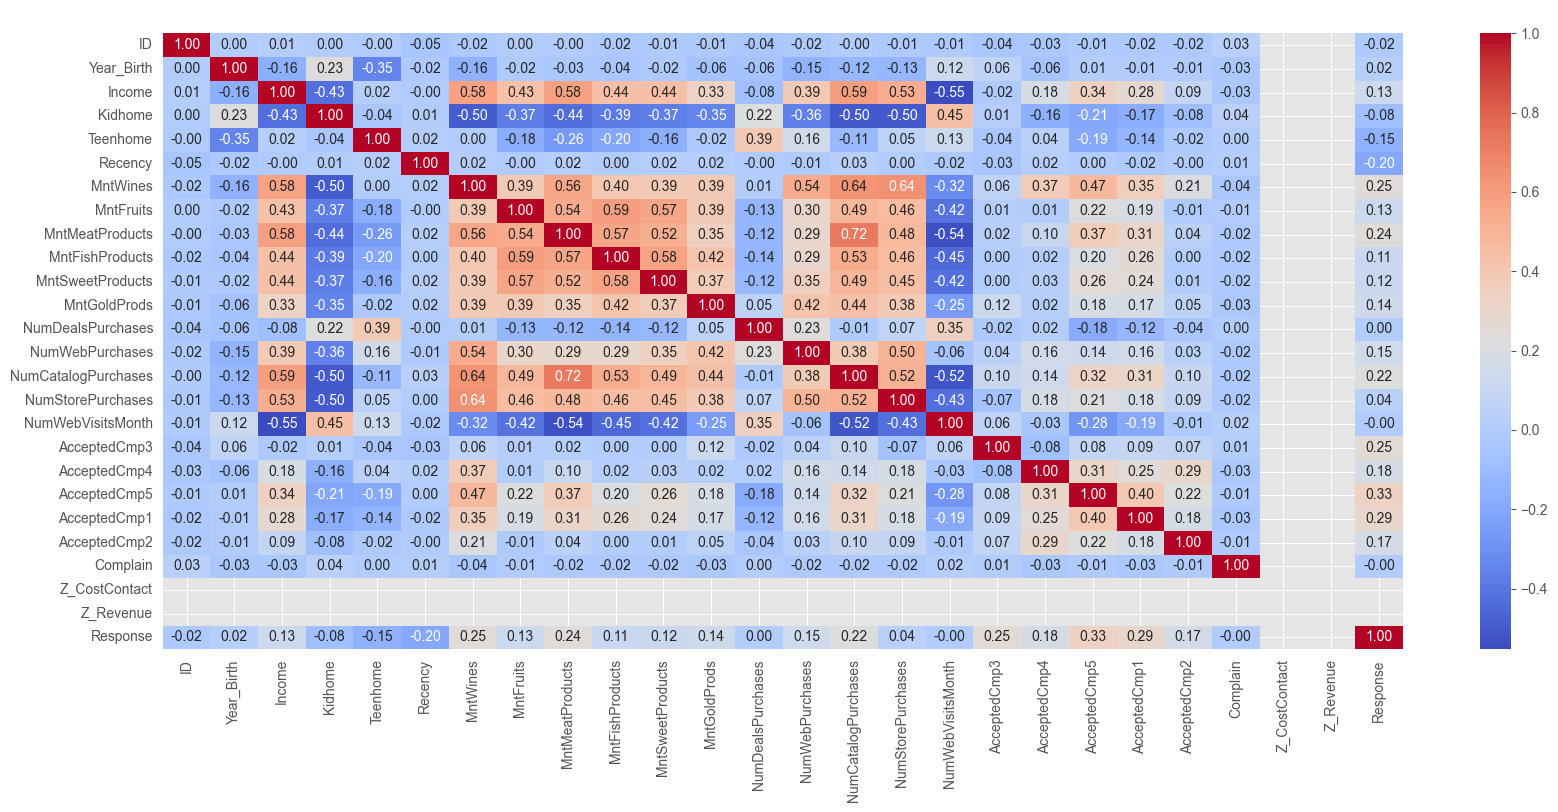

In [18]:
# Mapa de calor de correlación

num_data = data.select_dtypes(include=[np.number])

plt.figure(figsize=(20, 8))
sns.heatmap(num_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de Correlación")
plt.show()

In [19]:
num_data.corr()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,1.000000,0.000028,0.013095,0.002406,-0.002580,-0.046524,-0.022878,0.004600,-0.004437,-0.024475,...,-0.007446,-0.036040,-0.025387,-0.007517,-0.021614,-0.015061,0.033883,NaN,NaN,-0.021968
Year_Birth,0.000028,1.000000,-0.161791,0.230176,-0.352111,-0.019871,-0.157773,-0.017917,-0.030872,-0.041625,...,0.121139,0.061774,-0.060510,0.007123,-0.005930,-0.006539,-0.030128,NaN,NaN,0.021325
Income,0.013095,-0.161791,1.000000,-0.428669,0.019133,-0.003970,0.578650,0.430842,0.584633,0.438871,...,-0.553088,-0.016174,0.184400,0.335943,0.276820,0.087545,-0.027225,NaN,NaN,0.133047
Kidhome,0.002406,0.230176,-0.428669,1.000000,-0.036133,0.008827,-0.496297,-0.372581,-0.437129,-0.387644,...,0.447846,0.014674,-0.161600,-0.205634,-0.172339,-0.081716,0.040207,NaN,NaN,-0.080008
Teenhome,-0.002580,-0.352111,0.019133,-0.036133,1.000000,0.016198,0.004846,-0.176764,-0.261160,-0.204187,...,0.134884,-0.042677,0.038886,-0.191050,-0.140090,-0.015605,0.003138,NaN,NaN,-0.154446
Recency,-0.046524,-0.019871,-0.003970,0.008827,0.016198,1.000000,0.016064,-0.004306,0.023056,0.001079,...,-0.021445,-0.032991,0.018826,0.000129,-0.019283,-0.001781,0.013231,NaN,NaN,-0.198437
MntWines,-0.022878,-0.157773,0.578650,-0.496297,0.004846,0.016064,1.000000,0.389637,0.562667,0.399753,...,-0.320653,0.062202,0.373286,0.472613,0.354133,0.205907,-0.039007,NaN,NaN,0.247254
MntFruits,0.004600,-0.017917,0.430842,-0.372581,-0.176764,-0.004306,0.389637,1.000000,0.543105,0.594804,...,-0.418383,0.014727,0.010152,0.215833,0.194748,-0.009773,-0.005166,NaN,NaN,0.125289
MntMeatProducts,-0.004437,-0.030872,0.584633,-0.437129,-0.261160,0.023056,0.562667,0.543105,1.000000,0.568402,...,-0.539470,0.018272,0.102912,0.373769,0.309761,0.043033,-0.023483,NaN,NaN,0.236335
MntFishProducts,-0.024475,-0.041625,0.438871,-0.387644,-0.204187,0.001079,0.399753,0.594804,0.568402,1.000000,...,-0.446003,0.000357,0.016843,0.199578,0.260762,0.002577,-0.020953,NaN,NaN,0.111331


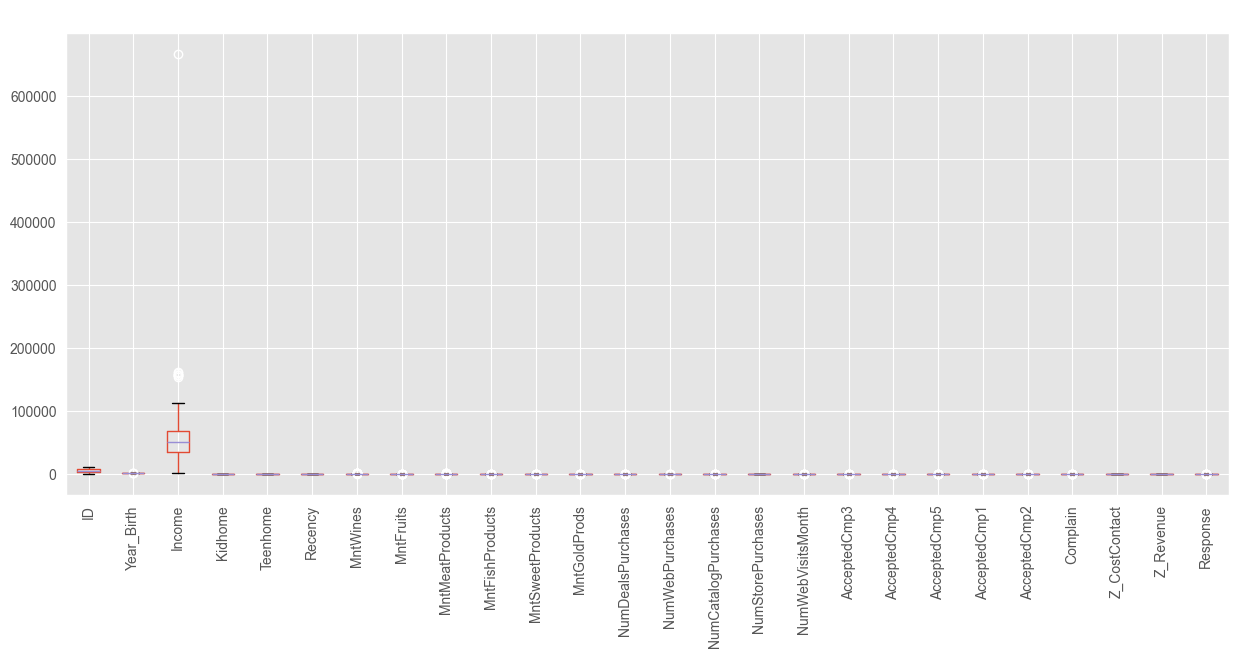

In [20]:
# Boxplots para detectar outliers
plt.figure(figsize=(15, 6))
num_data.boxplot(rot=90)
plt.title("Boxplots de Variables Numéricas")
plt.show()



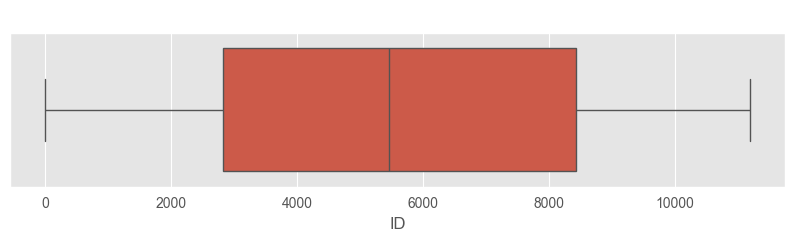

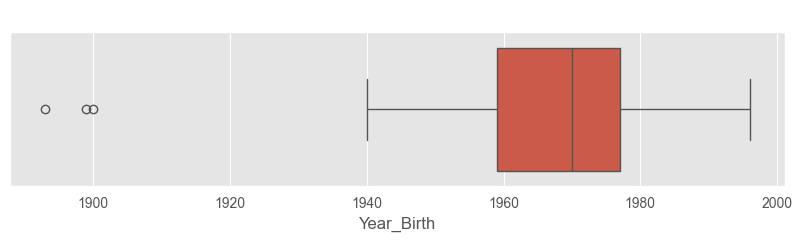

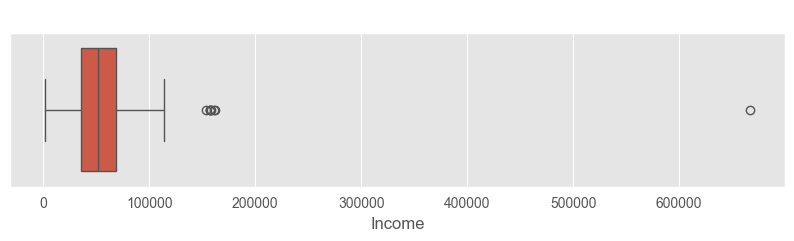

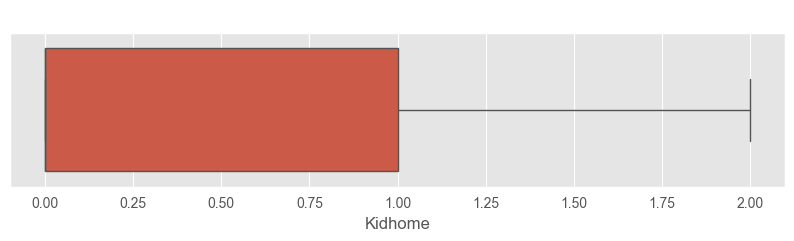

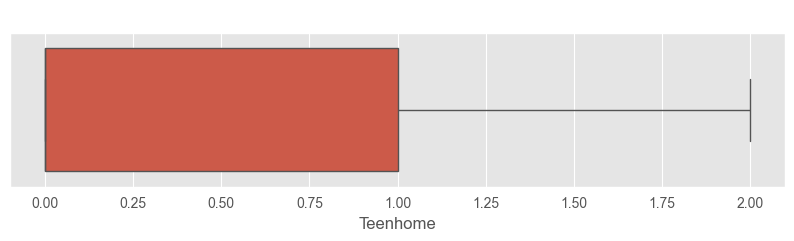

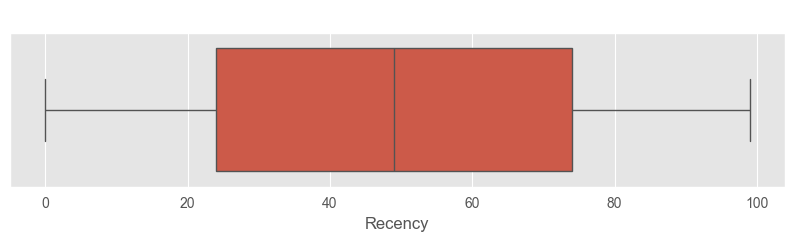

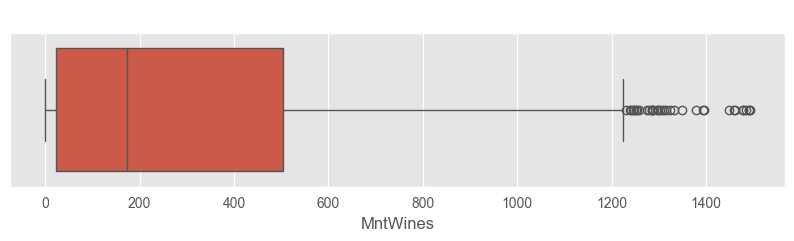

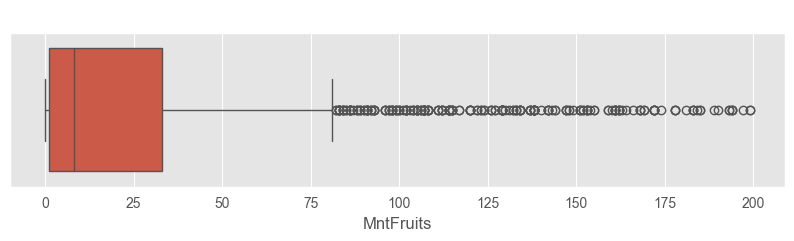

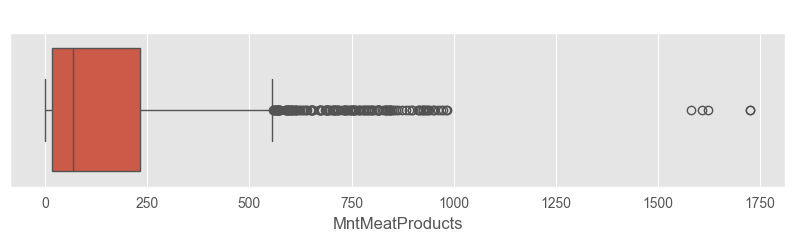

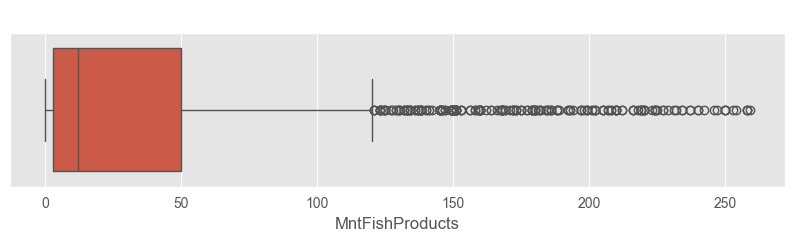

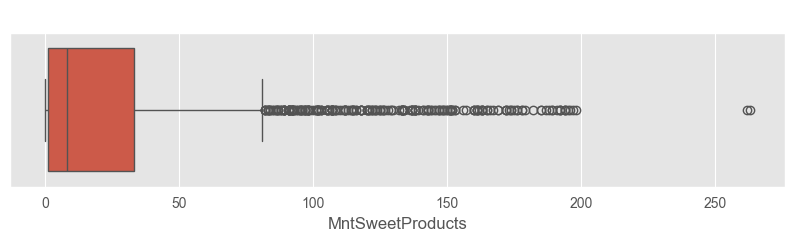

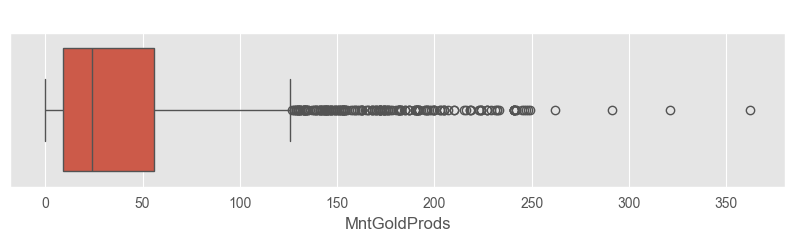

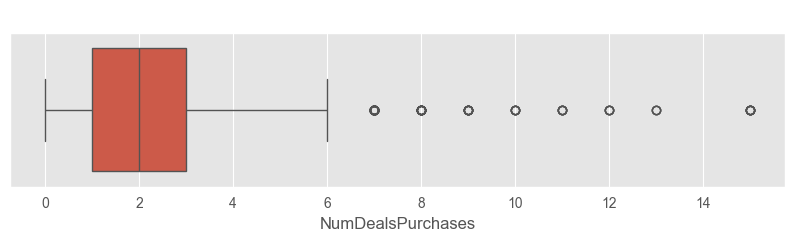

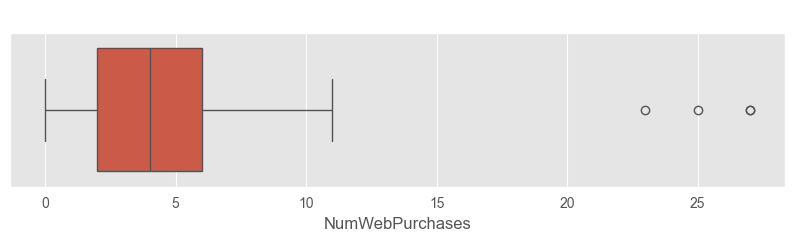

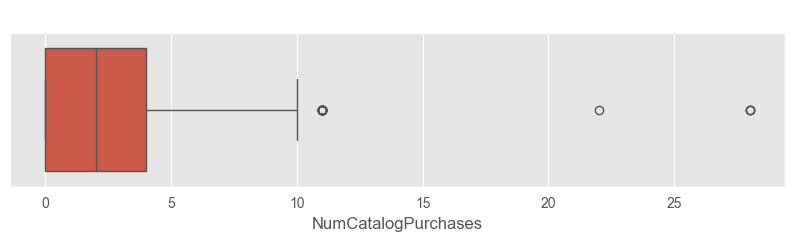

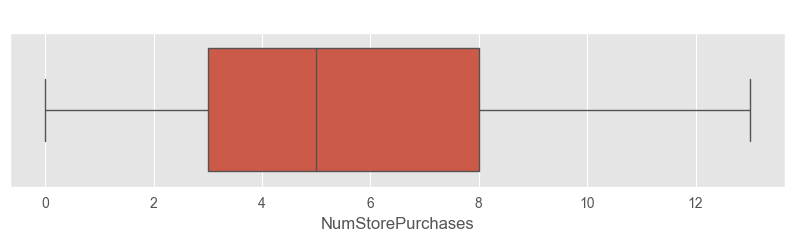

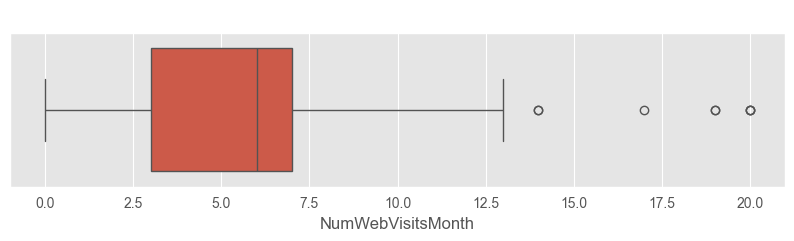

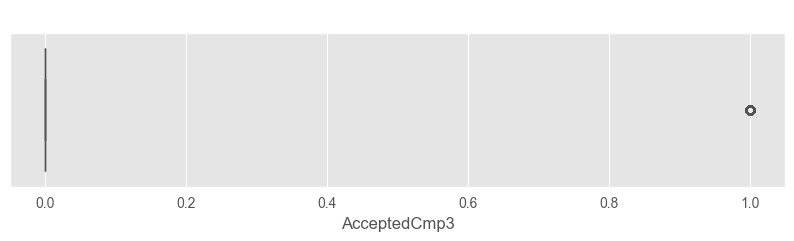

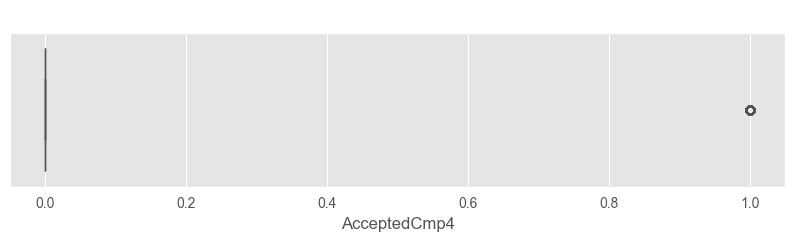

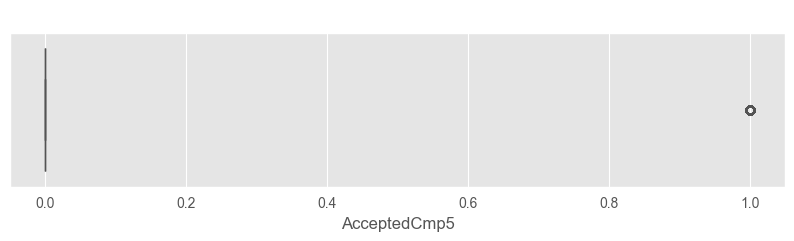

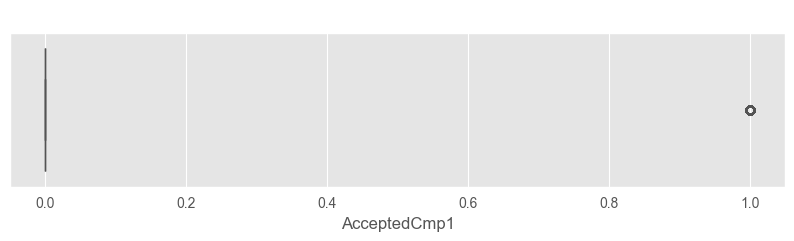

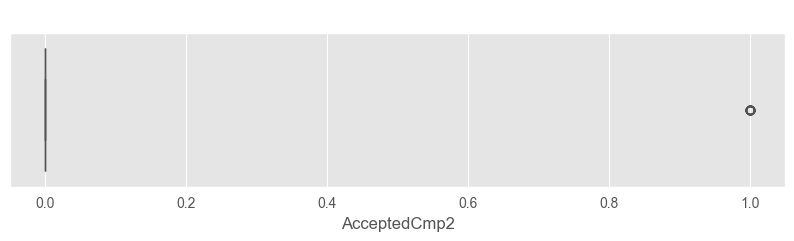

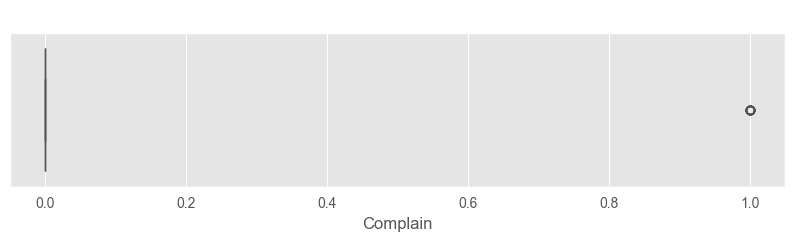

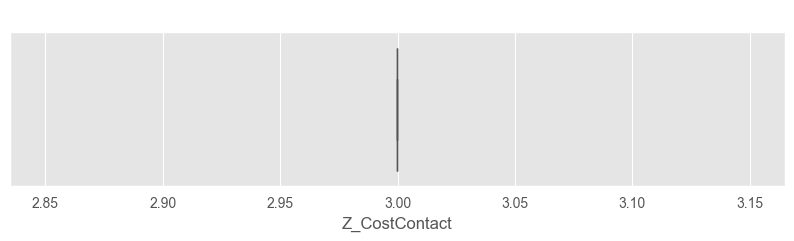

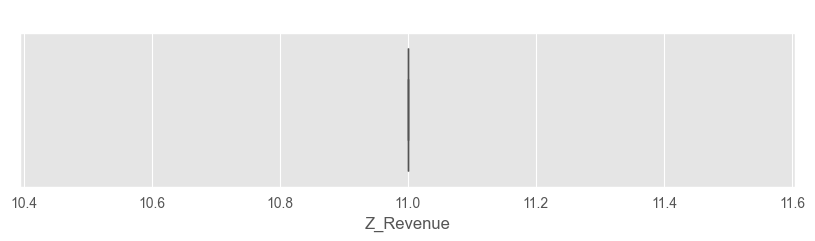

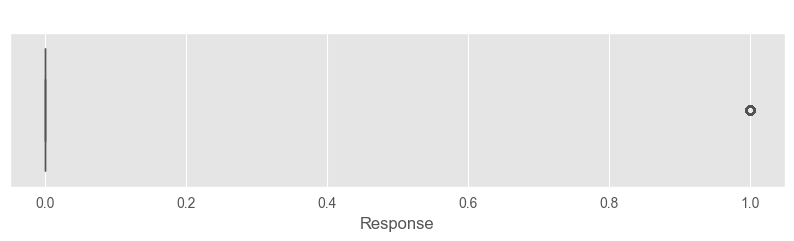

In [21]:
for col in num_data.columns:
  plt.figure(figsize=(10, 2))
  sns.boxplot(x=num_data[col])
  plt.title(f"Boxplot de {col}")
  plt.show()

In [22]:
(num_data["Income"]>130000).sum()

np.int64(8)

In [23]:
# Pairplot para relaciones entre variables
# sns.pairplot(data,hue='Education')
# plt.show()

In [24]:
# Pairplot para relaciones entre variables
# sns.pairplot(data,hue='Marital_Status', x_vars= ["Income","MntWines"], y_vars=["MntFishProducts","NumCatalogPurchases","Income"])
# plt.show()

C:\Users\JSSAMANIEGPO\AppData\Local\Temp\ipykernel_8492\4097607419.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col],palette="bright")


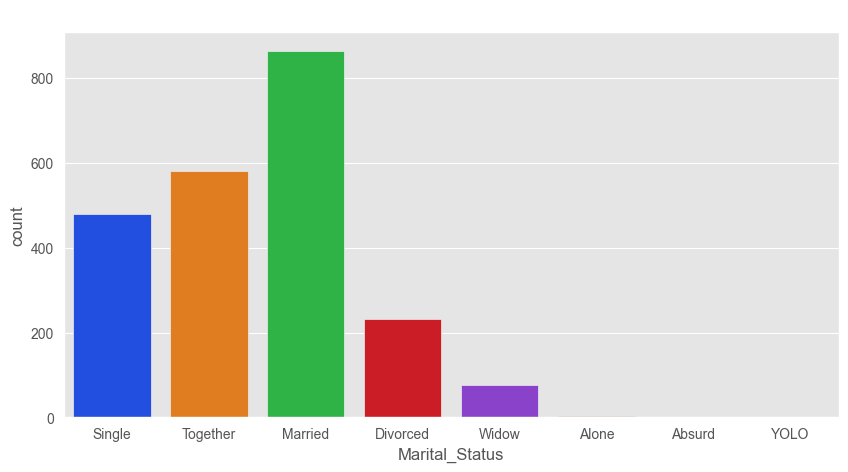

In [25]:
# Gráficos de barras para variables categóricas

# col = 'Education'
col = 'Marital_Status'

plt.figure(figsize=(10, 5))
sns.countplot(x=data[col],palette="bright")
plt.title(f"Distribución de {col}")
plt.show()

# }}}}


In [26]:
data.tail(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2230,7004,1984,Graduation,Single,11012.0,1,0,2013-03-16,82,24,...,9,1,0,0,0,0,0,3,11,0
2231,9817,1970,Master,Single,44802.0,0,0,2012-08-21,71,853,...,8,0,0,0,0,0,0,3,11,0
2232,8080,1986,Graduation,Single,26816.0,0,0,2012-08-17,50,5,...,4,0,0,0,0,0,0,3,11,0
2233,9432,1977,Graduation,Together,666666.0,1,0,2013-06-02,23,9,...,6,0,0,0,0,0,0,3,11,0
2234,8372,1974,Graduation,Married,34421.0,1,0,2013-07-01,81,3,...,7,0,0,0,0,0,0,3,11,0
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,2012-10-15,40,84,...,7,0,0,0,0,0,0,3,11,1


In [27]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   str           
 3   Marital_Status       2240 non-null   str           
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-null   int64  

In [28]:
##Revisión del sesgo en las variables numéricas
num_data.skew(axis=0) # Calculate skewness only for numerical columns

ID                      0.039832
Year_Birth             -0.349944
Income                  6.763487
Kidhome                 0.635288
Teenhome                0.407115
Recency                -0.001987
MntWines                1.175771
MntFruits               2.102063
MntMeatProducts         2.083233
MntFishProducts         1.919769
MntSweetProducts        2.136081
MntGoldProds            1.886106
NumDealsPurchases       2.418569
NumWebPurchases         1.382794
NumCatalogPurchases     1.880989
NumStorePurchases       0.702237
NumWebVisitsMonth       0.207926
AcceptedCmp3            3.291705
AcceptedCmp4            3.241574
AcceptedCmp5            3.291705
AcceptedCmp1            3.555444
AcceptedCmp2            8.472093
Complain               10.188972
Z_CostContact           0.000000
Z_Revenue               0.000000
Response                1.971555
dtype: float64

In [29]:
# # Instalamos la librería (si no está)
# !pip install ydata-profiling --quiet

# import pandas as pd
# from ydata_profiling import ProfileReport

# # 1. Cargar dataset
# df = pd.read_csv("/content/segmentacion.csv")

# # 2. Generar reporte de exploración
# profile = ProfileReport(
#     df,
#     title="Reporte Exploratorio - Segmentación",
#     explorative=True
# )

# # 3. Guardar reporte en HTML
# profile.to_file("/content/reporte_segmentacion.html")

# print("✅ Reporte generado: /content/reporte_segmentacion.html")


In [30]:
# from google.colab import files
# files.download("/content/reporte_segmentacion.html")

In [31]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0


# Preparación data Clusterización

In [32]:
from datetime import date
# Cálculo de variables derivadas: Antigüedad del cliente y Edad
data['Hoy'] = date.today()
data['Hoy'] = data['Hoy'].astype('datetime64[ns]')
data['Antiguedad'] = (data['Hoy'] - data['Dt_Customer']).dt.days / 365.25
data['Antiguedad'] = data['Antiguedad'].astype('int64')
data['Edad'] = 2026 - data['Year_Birth']

# Eliminación de columnas originales tras la transformación
data = data.drop(columns=['Hoy', 'Dt_Customer', 'Year_Birth'])

In [33]:
data

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Antiguedad,Edad
0,5524,Graduation,Single,58138.0,0,0,58,635,88,546,...,0,0,0,0,0,3,11,1,13,69
1,2174,Graduation,Single,46344.0,1,1,38,11,1,6,...,0,0,0,0,0,3,11,0,12,72
2,4141,Graduation,Together,71613.0,0,0,26,426,49,127,...,0,0,0,0,0,3,11,0,12,61
3,6182,Graduation,Together,26646.0,1,0,26,11,4,20,...,0,0,0,0,0,3,11,0,12,42
4,5324,PhD,Married,58293.0,1,0,94,173,43,118,...,0,0,0,0,0,3,11,0,12,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,Graduation,Married,61223.0,0,1,46,709,43,182,...,0,0,0,0,0,3,11,0,12,59
2236,4001,PhD,Together,64014.0,2,1,56,406,0,30,...,0,0,1,0,0,3,11,0,11,80
2237,7270,Graduation,Divorced,56981.0,0,0,91,908,48,217,...,1,0,0,0,0,3,11,0,12,45
2238,8235,Master,Together,69245.0,0,1,8,428,30,214,...,0,0,0,0,0,3,11,0,12,70


In [34]:
len(data)

2240

Imputación

In [35]:
media_income = data["Income"].mean()

In [36]:
media_income1 = data["Income"][(data["Income"]<100000)].mean()

In [59]:
from scipy.stats import trim_mean

# Definir el porcentaje de datos a recortar (por ejemplo, 10% de cada extremo)
truncation_percentage = 0.1  # 10%

# Calcular la media truncada
media_truncada = trim_mean(data["Income"], proportiontocut=truncation_percentage)



In [38]:
mediana_income = data["Income"].median()

In [60]:
print('Media:',media_income)
print('Media <100.000 :',media_income1)
print('Media truncada 10%:',media_truncada)
print('Mediana:',mediana_income)


Media: 52247.25135379061
Media <100.000 : 51512.04993191103
Media truncada 10%: 51647.10149082569
Mediana: 51381.5


In [40]:
# Imputación de valores nulos en 'Income' utilizando la mediana para evitar sesgos de outliers
data = data.replace("NaN", media_truncada)
data = data.replace(np.nan, media_truncada)

In [41]:
# Filtrado de valores atípicos (Outliers) basado en el análisis visual previo
data = data[(data["Edad"] < 90)]
data = data[(data["Income"] < 140000)]
data = data[(data["MntWines"] < 1500)]
data = data[(data["MntMeatProducts"] < 1000)]
data = data[(data["MntGoldProds"] < 250)]
data = data[(data["NumDealsPurchases"] < 10)]
data = data[(data["NumWebPurchases"] < 15)]
data = data[(data["NumCatalogPurchases"] < 12)]

In [42]:
len(data[(data["Edad"] > 90)])

0

In [61]:
len(data)

2180

In [44]:
id_ =data['ID']
id_ = pd.DataFrame(id_)

In [45]:
id_

,ID
0,5524
1,2174
2,4141
3,6182
4,5324
...,...
2235,10870
2236,4001
2237,7270
2238,8235


In [46]:
#Eliminar variables
data_segm=data.drop(columns = ['Z_CostContact','Complain','Z_Revenue','Response','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','AcceptedCmp1','AcceptedCmp2','ID'])

In [47]:
data_segm

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Antiguedad,Edad
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,13,69
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,12,72
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,12,61
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,12,42
4,PhD,Married,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,12,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduation,Married,61223.0,0,1,46,709,43,182,42,118,247,2,9,3,4,5,12,59
2236,PhD,Together,64014.0,2,1,56,406,0,30,0,0,8,7,8,2,5,7,11,80
2237,Graduation,Divorced,56981.0,0,0,91,908,48,217,32,12,24,1,2,3,13,6,12,45
2238,Master,Together,69245.0,0,1,8,428,30,214,80,30,61,2,6,5,10,3,12,70


In [48]:
# data_segm = data_segm.drop(columns = ['Hoy'])

In [49]:
# Transformación de variables categóricas a numéricas mediante One-Hot Encoding
data_segm = pd.get_dummies(data_segm, columns=data_segm.select_dtypes(exclude=['int64', 'float64']).columns, drop_first=True)

In [50]:
data_segm.select_dtypes(exclude=['int64','float64']).columns

Index(['Education_Basic', 'Education_Graduation', 'Education_Master',
       'Education_PhD', 'Marital_Status_Alone', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow',
       'Marital_Status_YOLO'],
      dtype='str')

In [51]:
data_segm

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,58138.0,0,0,58,635,88,546,172,88,88,...,True,False,False,False,False,False,True,False,False,False
1,46344.0,1,1,38,11,1,6,2,1,6,...,True,False,False,False,False,False,True,False,False,False
2,71613.0,0,0,26,426,49,127,111,21,42,...,True,False,False,False,False,False,False,True,False,False
3,26646.0,1,0,26,11,4,20,10,3,5,...,True,False,False,False,False,False,False,True,False,False
4,58293.0,1,0,94,173,43,118,46,27,15,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,0,1,46,709,43,182,42,118,247,...,True,False,False,False,False,True,False,False,False,False
2236,64014.0,2,1,56,406,0,30,0,0,8,...,False,False,True,False,False,False,False,True,False,False
2237,56981.0,0,0,91,908,48,217,32,12,24,...,True,False,False,False,True,False,False,False,False,False
2238,69245.0,0,1,8,428,30,214,80,30,61,...,False,True,False,False,False,False,False,True,False,False


**Normalización** Z Score

In [52]:
# Estandarización de las variables (media=0, desviación=1)
scaler = StandardScaler().fit(data_segm)
data_segm_scaled = pd.DataFrame(scaler.transform(data_segm), index=data_segm.index.values, columns=data_segm.columns.values)

In [53]:
data_segm_scaled.info()

<class 'pandas.DataFrame'>
Index: 2180 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Income                   2180 non-null   float64
 1   Kidhome                  2180 non-null   float64
 2   Teenhome                 2180 non-null   float64
 3   Recency                  2180 non-null   float64
 4   MntWines                 2180 non-null   float64
 5   MntFruits                2180 non-null   float64
 6   MntMeatProducts          2180 non-null   float64
 7   MntFishProducts          2180 non-null   float64
 8   MntSweetProducts         2180 non-null   float64
 9   MntGoldProds             2180 non-null   float64
 10  NumDealsPurchases        2180 non-null   float64
 11  NumWebPurchases          2180 non-null   float64
 12  NumCatalogPurchases      2180 non-null   float64
 13  NumStorePurchases        2180 non-null   float64
 14  NumWebVisitsMonth        2180 non-null  

In [54]:
data_segm_scaled

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,0.313520,-0.817331,-0.925470,0.306725,0.977544,1.539251,1.765555,2.445837,1.494671,0.872045,...,0.988144,-0.443269,-0.523554,-0.037122,-0.341765,-0.794050,1.920461,-0.589358,-0.188758,-0.030303
1,-0.259365,1.044509,0.918703,-0.386403,-0.871687,-0.640079,-0.736072,-0.654013,-0.636929,-0.738305,...,0.988144,-0.443269,-0.523554,-0.037122,-0.341765,-0.794050,1.920461,-0.589358,-0.188758,-0.030303
2,0.968058,-0.817331,-0.925470,-0.802279,0.358170,0.562310,-0.175522,1.333538,-0.146906,-0.031322,...,0.988144,-0.443269,-0.523554,-0.037122,-0.341765,-0.794050,-0.520708,1.696763,-0.188758,-0.030303
3,-1.216181,1.044509,-0.925470,-0.802279,-0.871687,-0.564930,-0.671215,-0.508138,-0.587926,-0.757944,...,0.988144,-0.443269,-0.523554,-0.037122,-0.341765,-0.794050,-0.520708,1.696763,-0.188758,-0.030303
4,0.321049,1.044509,-0.925470,1.554354,-0.391598,0.412011,-0.217216,0.148301,0.000101,-0.561559,...,-1.011999,-0.443269,1.910023,-0.037122,-0.341765,1.259366,-0.520708,-0.589358,-0.188758,-0.030303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,0.463371,-0.817331,0.918703,-0.109152,1.196844,0.412011,0.079273,0.075363,2.229705,3.994552,...,0.988144,-0.443269,-0.523554,-0.037122,-0.341765,1.259366,-0.520708,-0.589358,-0.188758,-0.030303
2236,0.598942,2.906349,0.918703,0.237412,0.298900,-0.665129,-0.624888,-0.690482,-0.661430,-0.699028,...,-1.011999,-0.443269,1.910023,-0.037122,-0.341765,-0.794050,-0.520708,1.696763,-0.188758,-0.030303
2237,0.257319,-0.817331,-0.925470,1.450385,1.786583,0.537260,0.241416,-0.106981,-0.367416,-0.384814,...,0.988144,-0.443269,-0.523554,-0.037122,2.925988,-0.794050,-0.520708,-0.589358,-0.188758,-0.030303
2238,0.853034,-0.817331,0.918703,-1.426094,0.364097,0.086364,0.227518,0.768271,0.073605,0.341807,...,-1.011999,2.255967,-0.523554,-0.037122,-0.341765,-0.794050,-0.520708,1.696763,-0.188758,-0.030303


# Kmeas


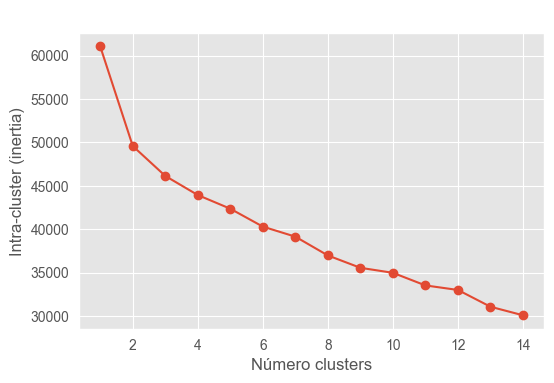

In [55]:
# Método elbow para identificar el número óptimo de clusters
# ==============================================================================
range_n_clusters = range(1, 15)
inertias = []

for n_clusters in range_n_clusters:
    modelo_kmeans = KMeans(
                        n_clusters   = n_clusters,
                        n_init       = 20,
                        random_state = 123
                    )
    modelo_kmeans.fit(data_segm_scaled)
    inertias.append(modelo_kmeans.inertia_)

fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(range_n_clusters, inertias, marker='o')
ax.set_title("Evolución de la varianza intra-cluster total")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Intra-cluster (inertia)');

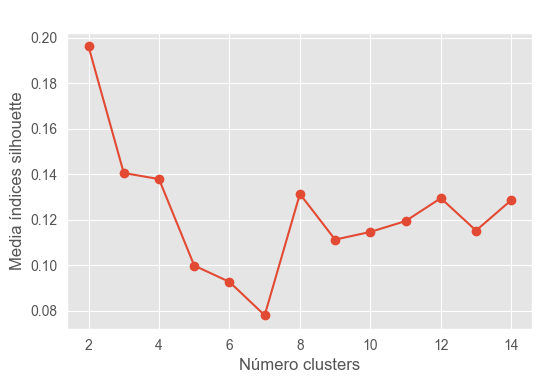

In [56]:
# Método silhouette para identificar el número óptimo de clusters
# ==============================================================================
range_n_clusters = range(2, 15)
valores_medios_silhouette = []

for n_clusters in range_n_clusters:
    modelo_kmeans = KMeans(
                        n_clusters   = n_clusters,
                        n_init       = 20,
                        random_state = 123
                    )
    cluster_labels = modelo_kmeans.fit_predict(data_segm_scaled)
    silhouette_avg = silhouette_score(data_segm_scaled, cluster_labels)
    valores_medios_silhouette.append(silhouette_avg)

fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(range_n_clusters, valores_medios_silhouette, marker='o')
ax.set_title("Evolución de media de los índices silhouette")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Media índices silhouette');

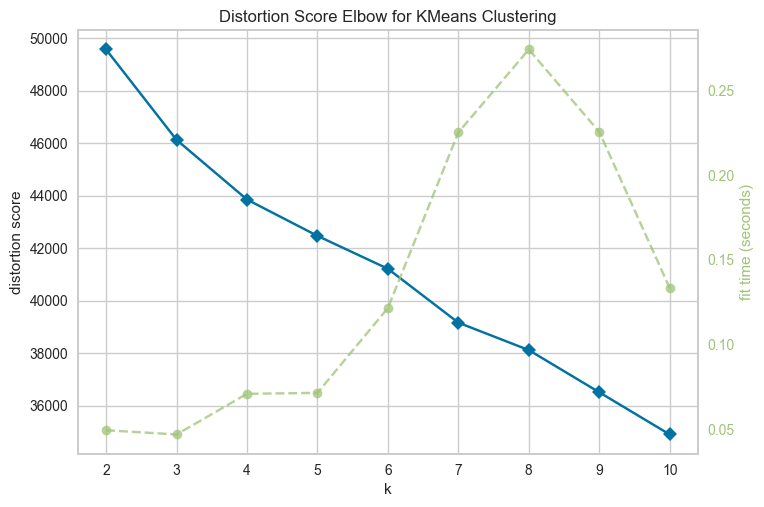

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [70]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# Usamos n_init=10 para estabilidad
model = KMeans(random_state=42, n_init=10)

# 1. Agregamos locate_elbow=False para silenciar la advertencia
# 2. Mantenemos force_model=True por si acaso
visualizer = KElbowVisualizer(model, k=(2, 11), force_model=True, locate_elbow=False)

visualizer.fit(data_segm_scaled)
visualizer.show()

In [71]:
modelo_kmeans = KMeans(n_clusters=5, n_init=20, random_state=1995)
modelo_kmeans.fit(data_segm_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",20
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1995
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


C:\Users\JSSAMANIEGPO\AppData\Local\Temp\ipykernel_8492\2180418099.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=modelo_kmeans.labels_, palette="bright")


<Axes: ylabel='count'>

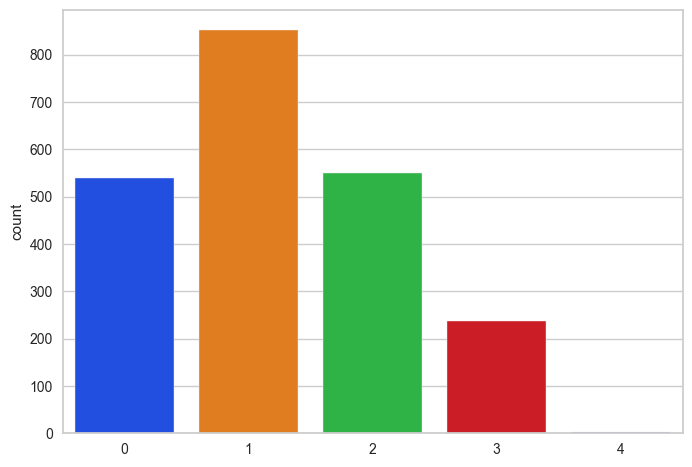

In [72]:
sns.countplot(x=modelo_kmeans.labels_, palette="bright")

In [73]:
data_segm['k-means_stand']=modelo_kmeans.labels_

In [74]:
data_segm.groupby('k-means_stand').mean().T

k-means_stand,0,1,2,3,4
Income,59042.230056,33869.454225,76035.400729,42678.573840,43789.000000
Kidhome,0.196660,0.795775,0.032787,0.641350,1.000000
Teenhome,0.916512,0.435446,0.160291,0.586498,0.666667
Recency,49.079777,49.688967,49.371585,47.092827,30.333333
MntWines,499.051948,40.183099,599.151184,137.097046,184.666667
MntFruits,24.918367,5.170188,70.265938,6.160338,4.000000
MntMeatProducts,146.499072,22.954225,453.681239,49.729958,26.333333
MntFishProducts,33.992579,7.931925,100.877960,8.713080,7.666667
MntSweetProducts,24.230056,5.281690,72.440801,6.329114,7.000000
MntGoldProds,62.573284,15.375587,77.854281,22.729958,27.000000


In [75]:
data_segm_scaled_fin = data_segm_scaled

data_segm_scaled_fin['k-means_stand'] = modelo_kmeans.labels_
data_segm_scaled_fin = data_segm_scaled_fin.groupby('k-means_stand').mean().T


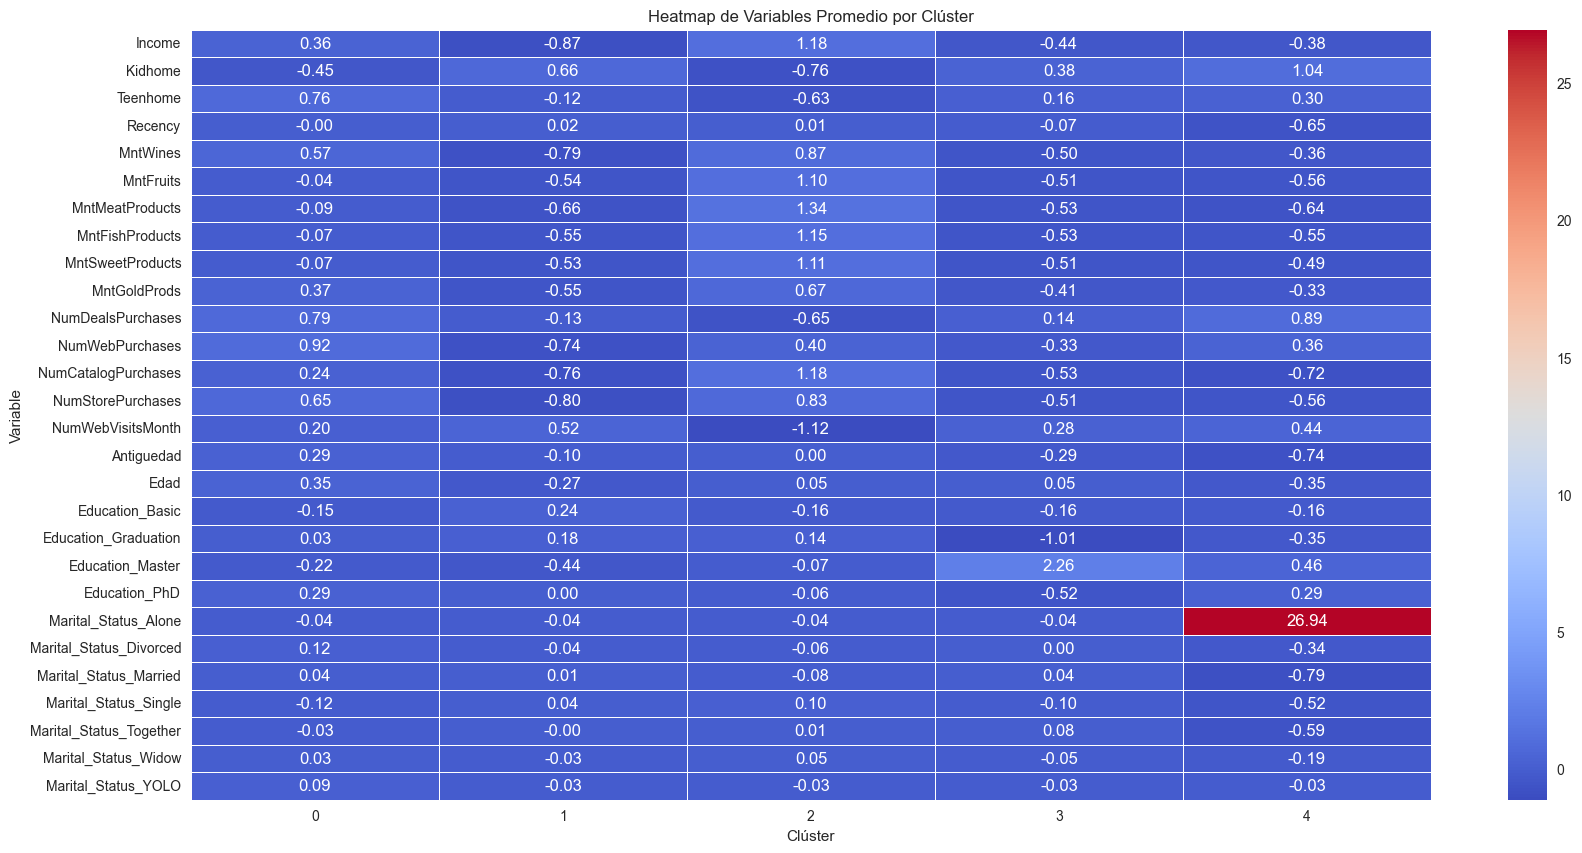

In [76]:
plt.figure(figsize=(20, 10))
sns.heatmap(data_segm_scaled_fin, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)

plt.title('Heatmap de Variables Promedio por Clúster')
plt.xlabel('Clúster')
plt.ylabel('Variable')
plt.show()

In [ ]:
data_segm.groupby('k-means_stand').count()

In [ ]:
# Pairplot para relaciones entre variables
# sns.pairplot(data_segm,hue='k-means_stand')
# plt.show()


In [ ]:
plt.figure()
pl=sns.swarmplot(x=data_segm["k-means_stand"], y=data_segm["Income"], color= "#CBEDDD", alpha=0.5 )
pl=sns.boxenplot(x=data_segm["k-means_stand"], y=data_segm["Income"])
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(data_segm_scaled, modelo_kmeans.labels_)
print("Índice de Silueta:", silhouette_avg)

# Kmeas PCA


In [ ]:
# Reducción a 9 componentes principales para capturar la mayor varianza posible
pca = PCA(n_components=9)
pca.fit(data_segm_scaled)
PCA_ds = pd.DataFrame(pca.transform(data_segm_scaled), columns=([f"col{i}" for i in range(1, 10)]))

# Varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_

In [ ]:
plt.plot(np.cumsum(explained_variance))
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Curva del Codo para PCA')
plt.grid()
plt.show()

In [ ]:
#A 3D Projection Of Data In The Reduced Dimension
x =PCA_ds["col1"]
y =PCA_ds["col2"]
z =PCA_ds["col3"]

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x,y,z)
plt.show()



In [ ]:
# Método elbow para identificar el número óptimo de clusters
# ==============================================================================
range_n_clusters = range(1, 15)
inertias = []

for n_clusters in range_n_clusters:
    modelo_kmeans = KMeans(
                        n_clusters   = n_clusters,
                        n_init       = 20,
                        random_state = 123
                    )
    modelo_kmeans.fit(PCA_ds)
    inertias.append(modelo_kmeans.inertia_)

fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(range_n_clusters, inertias, marker='o')
ax.set_title("Evolución de la varianza intra-cluster total")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Intra-cluster (inertia)');

In [ ]:
# Método silhouette para identificar el número óptimo de clusters
# ==============================================================================
range_n_clusters = range(2, 15)
valores_medios_silhouette = []

for n_clusters in range_n_clusters:
    modelo_kmeans = KMeans(
                        n_clusters   = n_clusters,
                        n_init       = 20,
                        random_state = 123
                    )
    cluster_labels = modelo_kmeans.fit_predict(PCA_ds)
    silhouette_avg = silhouette_score(PCA_ds, cluster_labels)
    valores_medios_silhouette.append(silhouette_avg)

fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(range_n_clusters, valores_medios_silhouette, marker='o')
ax.set_title("Evolución de media de los índices silhouette")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Media índices silhouette');

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(), k=10)
Elbow_M.fit(PCA_ds)
Elbow_M.show()

In [ ]:
modelo_kmeans_pca = KMeans(n_clusters=5, n_init=20, random_state=1995)
modelo_kmeans_pca.fit(PCA_ds)

In [ ]:
sns.countplot(x=modelo_kmeans_pca.labels_, palette="bright")

In [ ]:
data_segm['k-means_PCA']=modelo_kmeans_pca.labels_

In [ ]:
data_segm.groupby('k-means_PCA').mean().T

In [ ]:
PCA_ds_fin = PCA_ds
PCA_ds_fin['k-means_PCA']=modelo_kmeans_pca.labels_

In [ ]:
PCA_ds_fin_cluster = PCA_ds_fin.groupby('k-means_PCA').mean().T

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(PCA_ds_fin_cluster, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)

plt.title('Heatmap de Variables Promedio por Clúster')
plt.xlabel('Clúster')
plt.ylabel('Variable')
plt.show()

In [ ]:
data_segm.groupby('k-means_PCA').count()

In [ ]:
# # Pairplot para relaciones entre variables
# sns.pairplot(data_segm,hue='k-means_PCA')
# plt.show()


In [ ]:
plt.figure()
pl=sns.swarmplot(x=data_segm["k-means_PCA"], y=data_segm["Income"], color= "#CBEDDD", alpha=0.5 )
pl=sns.boxenplot(x=data_segm["k-means_PCA"], y=data_segm["Income"])
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(PCA_ds, modelo_kmeans_pca.labels_)
print("Índice de Silueta:", silhouette_avg)

#Dendrograma

In [ ]:
# Crear y visualizar el dendrograma

plt.figure(figsize=(10, 5))
sch.dendrogram(sch.linkage(data_segm_scaled, method='ward'))
plt.title('Dendrograma - Clustering Jerárquico')
plt.xlabel('Puntos de Datos')
plt.ylabel('Distancia Euclidiana')
plt.show()




In [ ]:
# Aplicar Clustering Jerárquico (seleccionar número de clusters)
n_clusters = 4  # Se puede ajustar según el dendrograma
hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels = hc.fit_predict(data_segm_scaled)

In [ ]:
#  Evaluar con el Índice de Silueta
silhouette_avg = silhouette_score(data_segm_scaled, labels)
print(f'Índice de Silueta: {silhouette_avg:.3f}')

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(data_segm_scaled)
    sil_score = silhouette_score(PCA_ds, labels)
    print(f'Clusters: {k}, Silueta: {sil_score:.3f}')


#Dendrograma PCA

In [ ]:
# Crear y visualizar el dendrograma
plt.figure(figsize=(10, 5))
sch.dendrogram(sch.linkage(PCA_ds, method='ward'))
plt.title('Dendrograma - Clustering Jerárquico')
plt.xlabel('Puntos de Datos')
plt.ylabel('Distancia Euclidiana')
plt.show()


In [ ]:
# Aplicar Clustering Jerárquico (seleccionar número de clusters)
n_clusters = 4  # Se puede ajustar según el dendrograma
hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels = hc.fit_predict(PCA_ds)

In [ ]:
#  Evaluar con el Índice de Silueta
silhouette_avg = silhouette_score(PCA_ds, labels)
print(f'Índice de Silueta: {silhouette_avg:.3f}')

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(PCA_ds)
    sil_score = silhouette_score(PCA_ds, labels)
    print(f'Clusters: {k}, Silueta: {sil_score:.3f}')
